# Error Analysis & Visualization

Với mỗi model đã train (`models/<experiment>_phobert/`), chạy dự đoán trên test set dùng chung (config `default` trên HF Hub), vẽ confusion matrix và trích ra các câu bị đoán sai để đọc thủ công.

Hàm load model / chạy inference / tính confusion matrix nằm ở `src/utils/evaluation.py` -- dùng chung, tránh mỗi notebook viết lại logic load model một kiểu khác nhau.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR / "data"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
ERROR_ANALYSIS_DIR = RESULTS_DIR / "error_analysis"

for d in [FIGURES_DIR, ERROR_ANALYSIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_DIR}")

Project root: D:\prj_it\Hate_Speech_Detection


In [4]:
from src.utils.evaluation import (
    LABELS, MODEL_DIR_NAME, available_experiments,
    load_model_and_tokenizer, predict_texts,
    compute_confusion_matrix, get_misclassified_examples,
)

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

d:\prj_it\Hate_Speech_Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Load test set dùng chung (config `default` trên HF Hub)

In [6]:
PROCESSED_DIR = DATA_DIR / "processed"

test_df = pd.read_csv(PROCESSED_DIR / "test.csv").dropna(subset=["text"]).reset_index(drop=True)
y_true = test_df["label"].map(label2id).tolist()
print(f"Test set: {test_df.shape}")

Test set: (6576, 4)


## Chạy dự đoán cho từng model đã train

In [7]:
experiments = available_experiments(MODELS_DIR)
print(f"Models found on disk: {experiments}")

predictions = {}
for experiment in experiments:
    print(f"Predicting with {experiment}...")
    model, tokenizer = load_model_and_tokenizer(MODELS_DIR, experiment, device=device)
    y_pred = predict_texts(model, tokenizer, test_df["text"].tolist(), device=device)
    predictions[experiment] = y_pred
    del model

Models found on disk: ['baseline', 'bt', 'eda', 'llm', 'voz', 'combined']
Predicting with baseline...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 564.06it/s]


Predicting with bt...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 670.20it/s]


Predicting with eda...


...

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 418.72it/s]


Predicting with voz...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 526.07it/s]


Predicting with combined...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 730.82it/s]


## Confusion matrix cho từng model

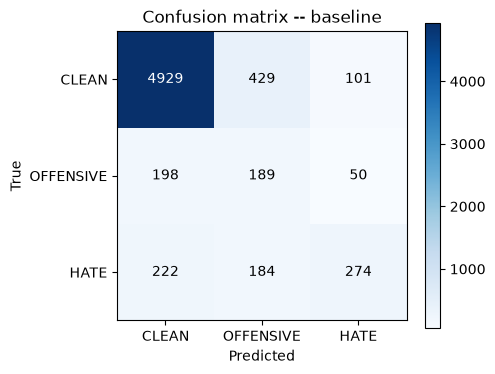

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_baseline.png


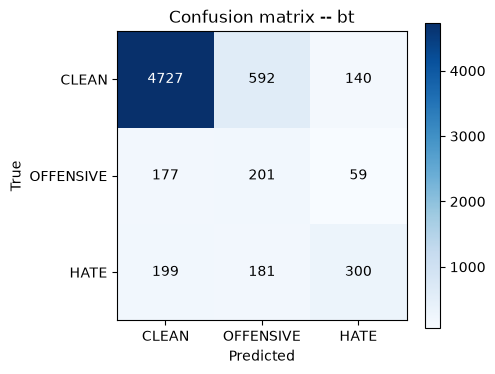

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_bt.png


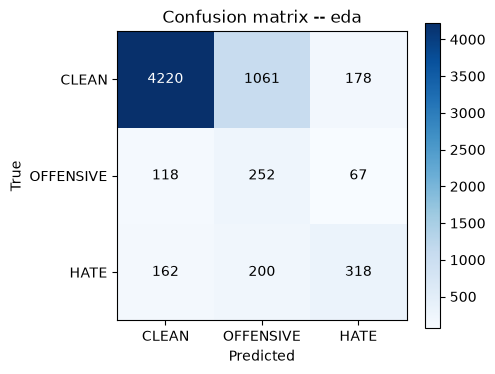

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_eda.png


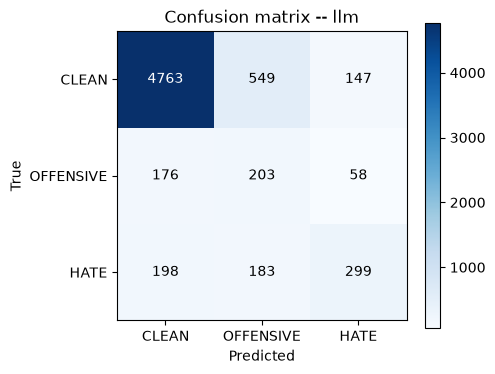

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_llm.png


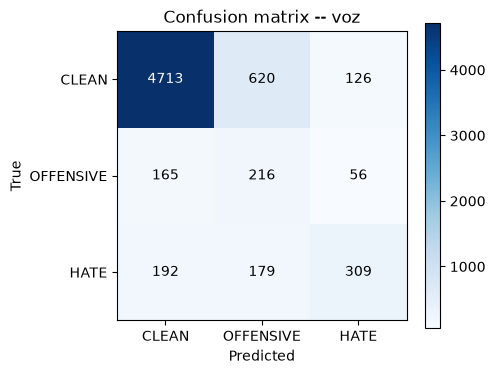

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_voz.png


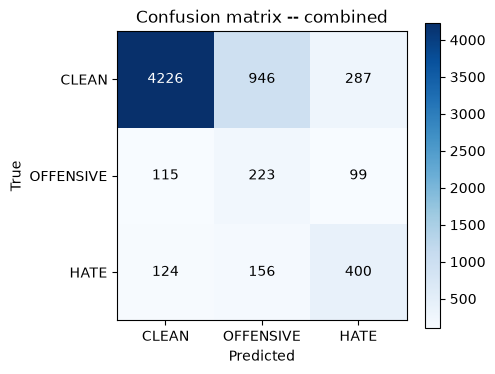

Saved: D:\prj_it\Hate_Speech_Detection\results\figures\confusion_matrix_combined.png


In [8]:
import itertools

def plot_confusion_matrix(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS)
    ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i, j in itertools.product(range(len(LABELS)), range(len(LABELS))):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

for experiment, y_pred in predictions.items():
    cm = compute_confusion_matrix(y_true, y_pred)
    save_path = FIGURES_DIR / f"confusion_matrix_{experiment}.png"
    plot_confusion_matrix(cm, f"Confusion matrix -- {experiment}", save_path)
    print(f"Saved: {save_path}")

## Trích các câu bị đoán sai (để đọc thủ công trong báo cáo)

In [9]:
N_EXAMPLES = 30

for experiment, y_pred in predictions.items():
    errors_df = get_misclassified_examples(
        test_df["text"].tolist(), y_true, y_pred, id2label, n=N_EXAMPLES
    )
    save_path = ERROR_ANALYSIS_DIR / f"misclassified_{experiment}.csv"
    errors_df.to_csv(save_path, index=False)
    print(f"{experiment}: {len(errors_df)} ví dụ lỗi (trong tổng số lỗi thực tế) -> {save_path}")

baseline: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_baseline.csv
bt: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_bt.csv
eda: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_eda.csv
llm: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_llm.csv
voz: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_voz.csv
combined: 30 ví dụ lỗi (trong tổng số lỗi thực tế) -> D:\prj_it\Hate_Speech_Detection\results\error_analysis\misclassified_combined.csv


## Tóm tắt: model nào nhầm lớp nào nhiều nhất?

Hữu ích để viết phần "phân tích lỗi" trong báo cáo -- ví dụ model hay nhầm OFFENSIVE thành CLEAN, hay nhầm HATE thành OFFENSIVE, v.v.

In [10]:
summary_rows = []
for experiment, y_pred in predictions.items():
    cm = compute_confusion_matrix(y_true, y_pred)
    for i, true_label in enumerate(LABELS):
        for j, pred_label in enumerate(LABELS):
            if i != j and cm[i, j] > 0:
                summary_rows.append({
                    "experiment": experiment,
                    "true_label": true_label,
                    "predicted_as": pred_label,
                    "count": int(cm[i, j]),
                })

confusion_summary_df = pd.DataFrame(summary_rows).sort_values(
    ["experiment", "count"], ascending=[True, False]
)
confusion_summary_df.to_csv(ERROR_ANALYSIS_DIR / "confusion_summary.csv", index=False)
confusion_summary_df

,experiment,true_label,predicted_as,count
0,baseline,CLEAN,OFFENSIVE,429
4,baseline,HATE,CLEAN,222
2,baseline,OFFENSIVE,CLEAN,198
5,baseline,HATE,OFFENSIVE,184
1,baseline,CLEAN,HATE,101
3,baseline,OFFENSIVE,HATE,50
6,bt,CLEAN,OFFENSIVE,592
10,bt,HATE,CLEAN,199
11,bt,HATE,OFFENSIVE,181
8,bt,OFFENSIVE,CLEAN,177
